In [118]:
#Pawel Maczuga and Maciej Paszynski (2023)
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial
# from google.colab import files
import time
import os
from typing import Tuple
from pathlib import Path
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Parameters

Skalowanie danych przepuszczalności do przedziału [0, 10].


In [119]:
def load_and_scale_kq(path):
    kq_layer = np.load(path)
    log_kq = np.log10(kq_layer + 1e-6)
    max_scale = 10.0
    l_min, l_max = log_kq.min(), log_kq.max()
    k_scaled = (log_kq - l_min) / (l_max - l_min) * (max_scale - 1.0) + 1.0
    scale = (1.0, max_scale)
    return k_scaled, scale

Pobieramy dane - te same, które wykorzystaliśmy w rozwiązaniu referencyjnym. Te dane to macierz o wymiarach 60 x 220. Rzeczywiste wymiary w metrach to ok. 366 x 671.

In [120]:
DATA_PATH = 'C:\PINN_mgr\FEniCS\solver-validation-newton-method\data\spe_model2_layer50.npy'
kq_data_matrix, scale = load_and_scale_kq(DATA_PATH)
ACTUAL_NY, ACTUAL_NX = kq_data_matrix.shape
print(ACTUAL_NX, ACTUAL_NY)
REAL_NX = ACTUAL_NX
REAL_NY = ACTUAL_NY

FT_TO_M = 0.3048
REAL_LX = REAL_NX * 20.0 * FT_TO_M
print(REAL_LX)
REAL_LY = REAL_NY * 10.0 * FT_TO_M
print(REAL_LY)

60 220
365.76
670.5600000000001


In [121]:
TOTAL_TIME = 10.                
N_POINTS_X = REAL_NX  
N_POINTS_Y = REAL_NY  
DT = 1.0
# N_POINTS_T = int(TOTAL_TIME/DT)
N_POINTS_T = 10

x_domain = [0.0, REAL_LX]
y_domain = [0.0, REAL_LY]
t_domain = [0.0, TOTAL_TIME]

WEIGHT_RESIDUAL = 100.0           # Weight of residual part of loss function
WEIGHT_INITIAL = 1.0            # Weight of initial part of loss function
WEIGHT_BOUNDARY = 1.0           # Weight of boundary part of loss function

LAYERS = 4
NEURONS_PER_LAYER = 8
EPOCHS = 200
LEARNING_RATE = 0.05

## Initial condition

In [122]:
def initial_condition(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    mid_x = REAL_LX / 2.0
    mid_y = REAL_LY / 2.0

    r = torch.sqrt((x - mid_x)**2 + (y - mid_y)**2)
    return (r <= 30.0).float()

## PINN


In [123]:
class PINN(nn.Module):
    """Simple neural network accepting two features as input and returning a single output

    In the context of PINNs, the neural network is used as universal function approximator
    to approximate the solution of the differential equation
    """
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh()):

        super().__init__()

        self.layer_in = nn.Linear(3, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 1)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, y, t):

        # x_stack = torch.cat([x, y, t], dim=1)
        #normalizacja 
        x_norm = x / REAL_LX
        y_norm = y / REAL_LY
        t_norm = t / TOTAL_TIME

        x_stack = torch.cat([x_norm, y_norm, t_norm], dim=1)
        out = self.act(self.layer_in(x_stack))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        logits = self.layer_out(out)

        return logits

    def device(self):
        return next(self.parameters()).device


def f(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """Compute the value of the approximate solution from the NN model"""
    return pinn(x, y, t)


def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    """Compute neural network derivative with respect to input features using PyTorch autograd engine"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(input),
            create_graph=True,
            retain_graph=True,
        )[0]

    return df_value


def dfdt(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, t, order=order)


def dfdx(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, x, order=order)

def dfdy(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, y, order=order)

## Loss function

In [124]:
from turtle import down


def get_boundary_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    """
         .+------+
       .' |    .'|
      +---+--+'  |
      |   |  |   |
    y |  ,+--+---+
      |.'    | .' t
      +------+'
         x
    """
    x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X, device=device)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y, device=device)
    t_linspace = torch.linspace(t_domain[0], t_domain[1], N_POINTS_T, device=device)

    #poziom

    x_grid_h, t_grid_h = torch.meshgrid( x_linspace, t_linspace, indexing="ij")
    x_grid_h = x_grid_h.reshape(-1, 1)
    t_grid_h = t_grid_h.reshape(-1, 1)

    y0 = torch.full_like(t_grid_h, y_domain[0], requires_grad=requires_grad)
    y1 = torch.full_like(t_grid_h, y_domain[1], requires_grad=requires_grad)

    if requires_grad:
        x_grid_h.requires_grad = True
        t_grid_h.requires_grad = True

    #pion
    y_grid_v, t_grid_v = torch.meshgrid( y_linspace, t_linspace, indexing="ij")
    y_grid_v = y_grid_v.reshape(-1, 1)
    t_grid_v = t_grid_v.reshape(-1, 1)

    x0 = torch.full_like(t_grid_v, x_domain[0], requires_grad=requires_grad)
    x1 = torch.full_like(t_grid_v, x_domain[1], requires_grad=requires_grad)

    if requires_grad:
        y_grid_v.requires_grad = True
        t_grid_v.requires_grad = True

    down  = (x_grid_h, y0,       t_grid_h)
    up    = (x_grid_h, y1,       t_grid_h)
    left  = (x0,       y_grid_v, t_grid_v)
    right = (x1,       y_grid_v, t_grid_v)

    return down, up, left, right

In [125]:
def get_initial_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X, device=device)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y, device=device)

    x_grid, y_grid = torch.meshgrid( x_linspace, y_linspace, indexing="ij")
    x_grid = x_grid.reshape(-1, 1)
    y_grid = y_grid.reshape(-1, 1)
    t0 = torch.full_like(x_grid, t_domain[0], device=device)

    if requires_grad:
        x_grid.requires_grad = True
        y_grid.requires_grad = True
        t0.requires_grad = True

    return (x_grid, y_grid, t0)

In [126]:
def get_interior_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    x_raw = torch.linspace(x_domain[0], x_domain[1], steps=N_POINTS_X, device=device)
    y_raw = torch.linspace(y_domain[0], y_domain[1], steps=N_POINTS_Y, device=device)
    t_raw = torch.linspace(t_domain[0], t_domain[1], steps=N_POINTS_T, device=device)
    grids = torch.meshgrid(x_raw, y_raw, t_raw, indexing="ij")

    x = grids[0].reshape(-1, 1) 
    y = grids[1].reshape(-1, 1) 
    t = grids[2].reshape(-1, 1) 

    if requires_grad:
        x.requires_grad = True
        y.requires_grad = True
        t.requires_grad = True  

    return x, y, t

In [127]:
KQ_TENSOR = torch.tensor(kq_data_matrix, dtype=torch.float32).to(device)

In [128]:
def Kq(x, y):
    x_norm = x / REAL_LX
    y_norm = y / REAL_LY
    
    idx_x = (x_norm * (REAL_NX - 1)).long()
    idx_y = (y_norm * (REAL_NY - 1)).long()

    idx_x = torch.clamp(idx_x, 0, REAL_NX - 1)
    idx_y = torch.clamp(idx_y, 0, REAL_NY - 1)

    return KQ_TENSOR[idx_y, idx_x]

def K(x, y, u):
    return Kq(x, y) * torch.exp(10.0 * u)

def source_term(name, x, y):
    if name == "h=0":
        return 0.0
    else:
        x_n = x / REAL_LX
        y_n = y / REAL_LY
        return 1.0 + torch.sin(2 * np.pi * x_n) * torch.sin(2 * np.pi * y_n)


In [129]:
class Loss:
    def __init__(
        self,
        x_domain: Tuple[float, float],
        y_domain: Tuple[float, float],
        t_domain: Tuple[float, float],
        # n_points: int,
        N_POINTS_T: int,
        initial_condition: Callable,
        weight_r: float = 1.0,
        weight_b: float = 1.0,
        weight_i: float = 1.0,
        verbose: bool = False,
    ):
        self.x_domain = x_domain
        self.y_domain = y_domain
        self.t_domain = t_domain
        self.N_POINTS_T = N_POINTS_T
        self.initial_condition = initial_condition
        self.weight_r = weight_r
        self.weight_b = weight_b
        self.weight_i = weight_i

    def residual_loss(self, pinn: PINN):
        x, y, t = get_interior_points(self.x_domain, self.y_domain, self.t_domain, pinn.device())
        u = f(pinn, x, y, t)
        
        du_dx = dfdx(pinn, x, y, t)
        du_dy = dfdy(pinn, x, y, t)
        
        K_val = K(x, y, u)

        flux_x = K_val * du_dx
        flux_y = K_val * du_dy

        d_flux_x_dx = df(flux_x, x)
        d_flux_y_dy = df(flux_y, y)
        div_flux = d_flux_x_dx + d_flux_y_dy

        u_t = dfdt(pinn, x, y, t)
        source = source_term("h=1", x, y)
        res = u_t - div_flux - source

        return res.pow(2).mean()


    def initial_loss(self, pinn: PINN):
        x, y, t = get_initial_points(self.x_domain, self.y_domain, self.t_domain, pinn.device())
        pinn_init = self.initial_condition(x, y)
        loss = f(pinn, x, y, t) - pinn_init
        return loss.pow(2).mean()

    def boundary_loss(self, pinn: PINN):
        down, up, left, right = get_boundary_points(
            self.x_domain, self.y_domain, self.t_domain, pinn.device()
        )

        u_down  = f(pinn, *down)
        u_up    = f(pinn, *up)
        u_left  = f(pinn, *left)
        u_right = f(pinn, *right)
    
        loss = u_down.pow(2).mean() + \
               u_up.pow(2).mean()   + \
               u_left.pow(2).mean() + \
               u_right.pow(2).mean()

        return loss

    def verbose(self, pinn: PINN):
        """
        Returns all parts of the loss function

        Not used during training! Only for checking the results later.
        """
        residual_loss = self.residual_loss(pinn)
        initial_loss = self.initial_loss(pinn)
        boundary_loss = self.boundary_loss(pinn)

        final_loss = \
            self.weight_r * residual_loss + \
            self.weight_i * initial_loss + \
            self.weight_b * boundary_loss

        return final_loss, residual_loss, initial_loss, boundary_loss

    def __call__(self, pinn: PINN):
        """
        Allows you to use instance of this class as if it was a function:

        ```
            >>> loss = Loss(*some_args)
            >>> calculated_loss = loss(pinn)
        ```
        """
        return self.verbose(pinn)[0]

## Train function

In [130]:
def train_model(
    nn_approximator: PINN,
    loss_fn: Callable,
    learning_rate: float = 0.01,
    max_epochs: int = 1_000
) -> Tuple[PINN, dict]:

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)

    history = {
        'total': [],
        'residual': [],
        'initial': [],
        'boundary': []
    }

    for epoch in range(max_epochs):

        try:
            total_l, res_l, init_l, bnd_l = loss_fn.verbose(nn_approximator)
            optimizer.zero_grad()

            total_l.backward()
            optimizer.step()

            history['total'].append(total_l.detach().item())
            history['residual'].append(res_l.detach().item())
            history['initial'].append(init_l.detach().item())
            history['boundary'].append(bnd_l.detach().item())

            if (epoch + 1) % 1000 == 0:
                print(f"Epoch: {epoch + 1} - Total Loss: {total_l.item():.6f}")

        except KeyboardInterrupt:
            break

    return nn_approximator, history


In [131]:
def get_pinn_map(model, t_value):
    model.eval()
    with torch.no_grad():
        x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X, device=device)
        y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y, device=device)
        X, Y = torch.meshgrid(x_linspace, y_linspace, indexing="ij")
        
        T = torch.full_like(X, t_value)
        u_pred = model(X.reshape(-1, 1), Y.reshape(-1, 1), T.reshape(-1, 1))
        u_map = u_pred.reshape(N_POINTS_X, N_POINTS_Y).cpu().numpy()
        
        save_dir = Path("results/maps_to_compare")
        save_dir.mkdir(parents=True, exist_ok=True)

        file_path = save_dir / f"pinn_map_t{t_value}_NT{N_POINTS_T}_lr{LEARNING_RATE}_ep{EPOCHS}.npy"

        data_to_save = {
            "u_pinn": u_map,
            "t": t_value,
            "x_grid": X.cpu().numpy(),
            "y_grid": Y.cpu().numpy()
        }
        
        np.save(file_path, data_to_save)

        return u_map

## Plotting functions

In [132]:
def plot_color(z, title, x=None, y=None, n_x=None, n_y=None, figsize=(12, 4), dpi=100, cmap="viridis"):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    z_np = z.detach().cpu().numpy() if torch.is_tensor(z) else z
    
    if n_x is not None and n_y is not None:
        z_map = z_np.reshape(n_x, n_y)
    else:
        z_map = z_np

    c = ax.imshow(z_map.T, origin='lower', extent=[0, REAL_LX, 0, REAL_LY], cmap=cmap, aspect='auto')
    
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    fig.colorbar(c, ax=ax)
    
    return fig
def running_average(y, window=100):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

# Running code

## Train data

In [133]:
pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

x_domain = [0.0, REAL_LX]
y_domain = [0.0, REAL_LY]
t_domain = [0.0, TOTAL_TIME]

loss_fn = Loss(
    x_domain,
    y_domain,
    t_domain,
    N_POINTS_T,
    initial_condition,
    WEIGHT_RESIDUAL,
    WEIGHT_INITIAL,
    WEIGHT_BOUNDARY
)

pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

pinn_trained, history = train_model(
    pinn, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)

# final_map = get_pinn_map(pinn_trained, t_value=TOTAL_TIME)

In [134]:
def plot_pinn_vs_fenics(u_pinn, u_fenics, t_value):
    
    error_map = np.abs(u_pinn - u_fenics)
    
    l2_error = np.linalg.norm(u_fenics - u_pinn) / np.linalg.norm(u_fenics)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    
    settings = {'origin': 'lower', 'extent': [0, REAL_LX, 0, REAL_LY], 'aspect': 'equal'}

    im0 = axes[0].imshow(u_fenics.T, cmap='viridis', **settings)
    axes[0].set_title(f"FEniCS (Referencja) t={t_value}")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(u_pinn.T, cmap='viridis', **settings)
    axes[1].set_title(f"PINN (Model) t={t_value}")
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(error_map.T, cmap='hot', **settings)
    axes[2].set_title(f"Błąd Bezwzględny (L2: {l2_error:.2e})")
    fig.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")

    plt.tight_layout()
    plt.show()

In [135]:
fenics_data = np.load(r'C:\PINN_mgr\FEniCS\solver-validation-newton-method\results\metrics\fenics_for_pinn_T1000_dt1_u_coeff10_h_0.npy', allow_pickle=True).item()
u_f = fenics_data['u_fenics']

In [136]:
u_p = get_pinn_map(pinn_trained, t_value=10.0)

In [137]:
print(f"Kształt PINN:   {u_p.shape}")
print(f"Kształt FEniCS: {u_f.shape}")

print(type(u_p))
print(type(u_f))

Kształt PINN:   (60, 220)
Kształt FEniCS: (220, 60)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


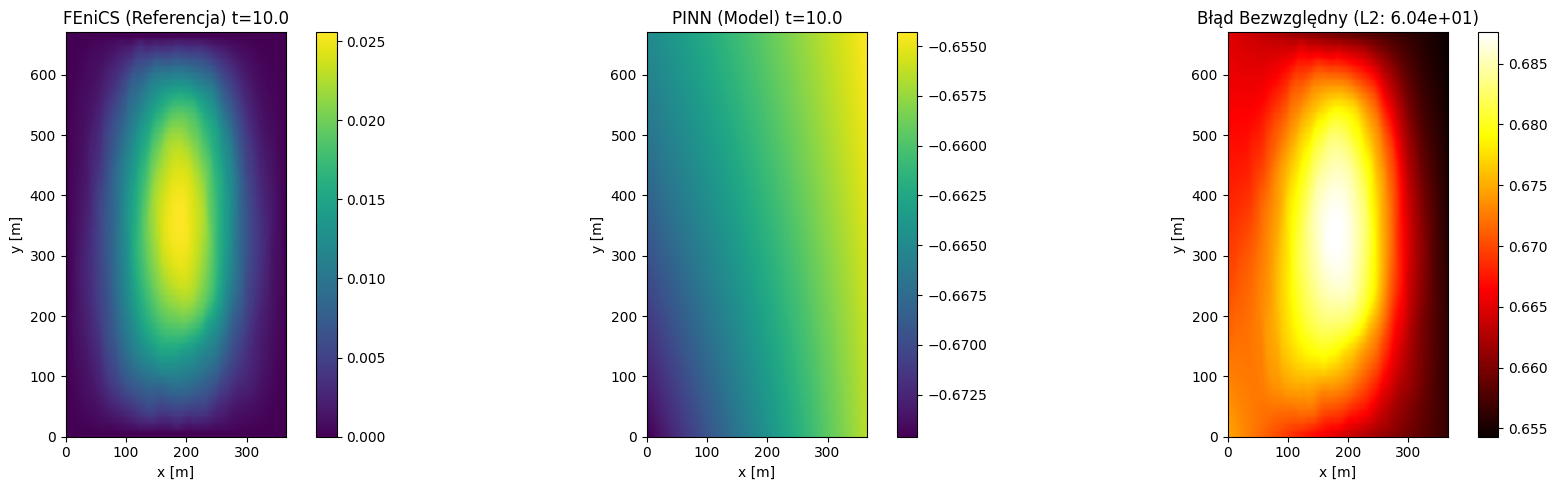

In [138]:
plot_pinn_vs_fenics(u_p.T, u_f, 10.0)

# Plotting

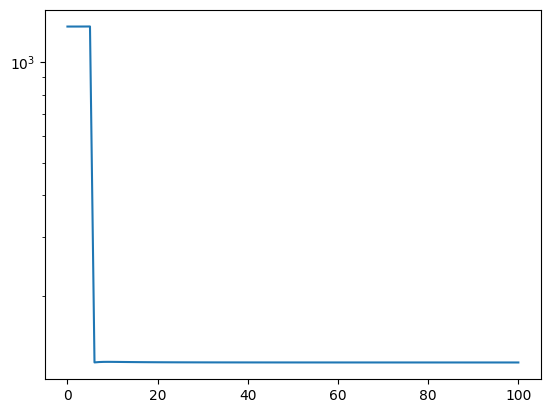

In [139]:
plt.plot(running_average(np.array(history['total']), window=100))
plt.yscale('log')
plt.show()

In [140]:
x_test = torch.linspace(x_domain[0], x_domain[1], REAL_NX, device=device)
y_test = torch.linspace(y_domain[0], y_domain[1], REAL_NY, device=device)
X, Y = torch.meshgrid(x_test, y_test, indexing="ij")

x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

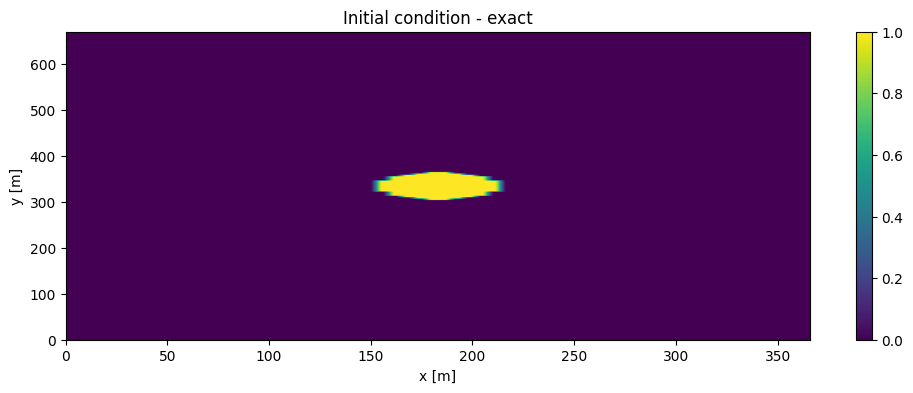

In [141]:
z_exact = initial_condition(x_flat, y_flat)
fig1 = plot_color(z_exact, "Initial condition - exact", n_x=REAL_NX, n_y=REAL_NY)

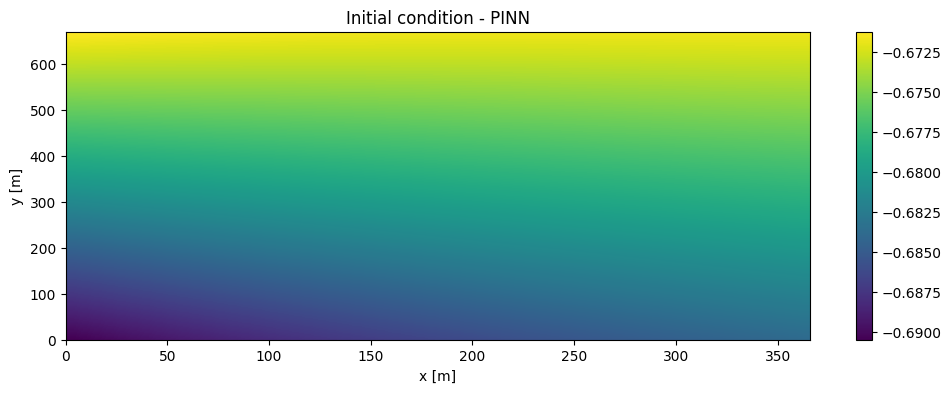

In [142]:
t_zero = torch.zeros_like(x_flat)
z_pinn = pinn(x_flat, y_flat, t_zero)
fig2 = plot_color(z_pinn, "Initial condition - PINN", n_x=REAL_NX, n_y=REAL_NY)

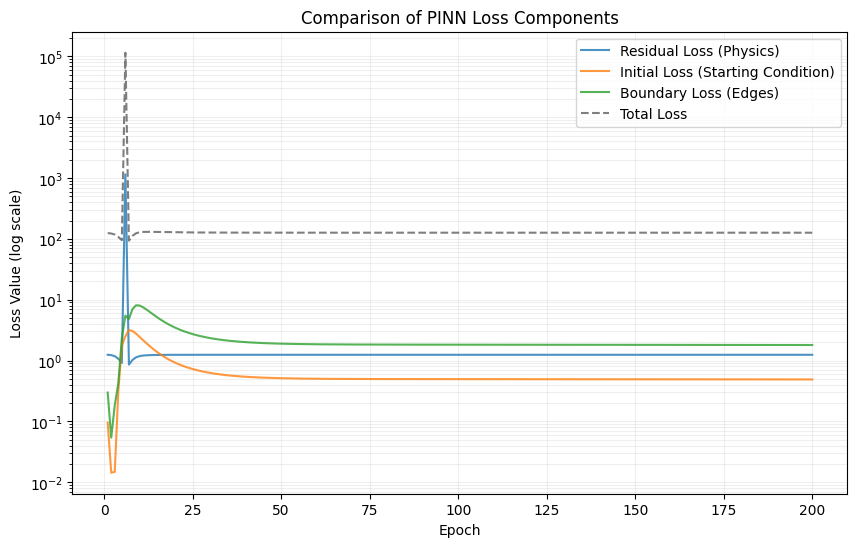

In [143]:
def plot_loss_comparison(history):
    plt.figure(figsize=(10, 6), dpi=100)

    epochs = range(1, len(history['total']) + 1)

    plt.plot(epochs, history['residual'], label='Residual Loss (Physics)', alpha=0.8)
    plt.plot(epochs, history['initial'], label='Initial Loss (Starting Condition)', alpha=0.8)
    plt.plot(epochs, history['boundary'], label='Boundary Loss (Edges)', alpha=0.8)

    plt.plot(epochs, history['total'], label='Total Loss', color='black', linestyle='--', alpha=0.5)

    plt.yscale('log')
    plt.title("Comparison of PINN Loss Components")
    plt.xlabel("Epoch")
    plt.ylabel("Loss Value (log scale)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_loss_comparison(history)